In [4]:
import ast

s = '''
True
None
match a:
    case 3:
        pass
    case True:
        pass
'''

print(ast.dump(ast.parse(s), indent=2))

Module(
  body=[
    Expr(
      value=Constant(value=True)),
    Expr(
      value=Constant(value=None)),
    Match(
      subject=Name(id='a', ctx=Load()),
      cases=[
        match_case(
          pattern=MatchValue(
            value=Constant(value=3)),
          body=[
            Pass()]),
        match_case(
          pattern=MatchSingleton(value=True),
          body=[
            Pass()])])])


In [3]:
from guppylang import guppy
from hugr.hugr.render import RenderConfig

@guppy
def f(x: int) -> int:
    y = x + 1
    return y

@guppy
def main(b: bool, m: int) -> None:
    l = True
    match l:
        case True:
            pass


main.compile_function().modules[0].render_dot()

___________________
BB id: 0
  Statements: Assign(targets=[Name(id='l', ctx=Store())], value=Constant(value=True, kind=None), type_comment=None)
  Predecessors: []
  Successors: [2, 3]
  prec_branches: MatchPred(patterns=[MatchValue(value=Constant(value=True, kind=None))], subject=Name(id='l', ctx=Load()))
------------------
___________________
BB id: 2
  Statements: 
  Predecessors: [0]
  Successors: [4]
  prec_branches: None
------------------
___________________
BB id: 3
  Statements: 
  Predecessors: [0]
  Successors: [4]
  prec_branches: None
------------------
___________________
BB id: 4
  Statements: 
  Predecessors: [2, 3]
  Successors: [1]
  prec_branches: None
------------------
___________________
BB id: 1
  Statements: 
  Predecessors: [4]
  Successors: []
  prec_branches: None
------------------


Traceback (most recent call last):
  File "/Users/nicola.assolini/Documents/GitHub/guppylang/.devenv/state/venv/lib/python3.14/site-packages/IPython/core/interactiveshell.py", line 3701, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/sx/bbzfd6mn5txdvh5bghnjgp5m0000gp/T/ipykernel_47506/570937899.py", line 17, in <module>
    main.compile_function().modules[0].render_dot()
    ~~~~~~~~~~~~~~~~~~~~~^^
  File "/Users/nicola.assolini/Documents/GitHub/guppylang/guppylang/src/guppylang/defs.py", line 205, in compile_function
    return super().compile()
           ~~~~~~~~~~~~~~~^^
  File "/Users/nicola.assolini/Documents/GitHub/guppylang/guppylang/src/guppylang/defs.py", line 77, in compile
    package: Package = ENGINE.compile(self.id).package
                       ~~~~~~~~~~~~~~^^^^^^^^^
  File "/Users/nicola.assolini/Documents/GitHub/guppylang/guppylang-internals/src/guppylang_internals/error.py

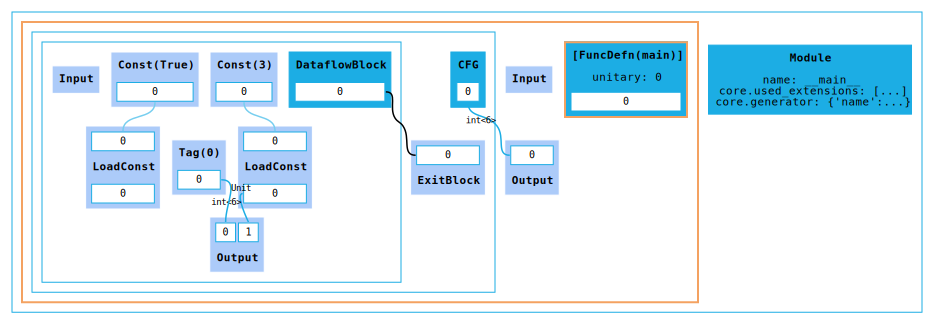

In [7]:
from guppylang import guppy

@guppy
def main() -> int:
    x = True
    return 3


main.compile_function().modules[0].render_dot()

In [13]:
# Example: linear variable used in multiple match arms (should error if not allowed)
from guppylang import guppy
from guppylang.std.quantum import qubit, measure, owned, h

@guppy.struct
class Point:
    y: int

@guppy
def fun() -> Point:
    return Point( 4)

@guppy
def main(p: Point) -> None:
    s = Point(0)
    if s == p:
        pass


main.compile_function()


Error: Operator not defined (at <In[13]>:16:7)
   | 
14 | def main(p: Point) -> None:
15 |     s = Point(0)
16 |     if s == p:
   |        ^^^^^^ Binary operator `==` not defined for `Point` and `Point`

Guppy compilation failed due to 1 previous error


In [ ]:
# Example: linear variable used in multiple match arms (should error if not allowed)
from guppylang import guppy
from guppylang.std.quantum import qubit, measure, owned, h

@guppy.enum
class Point:
    x = {"n": qubit}

@guppy
def fun() -> Point:
    return Point.x(qubit())

@guppy
def main(p: Point) -> None:
    match p:
        case Point.x(_):
            pass

main.compile_function()


In [ ]:
# Example: linear variable used in multiple match arms (should error if not allowed)
from guppylang import guppy
from guppylang.std.quantum import qubit, measure, h

@guppy.struct
class Point:
    x: qubit
    y: int

@guppy
def fun() -> Point:
    return Point(qubit(), 4)

@guppy
def describe_point(point: Point)-> None:
    pass

@guppy
def main(p: Point) -> None:

    describe_point(fun())

main.check()


In [ ]:
# Example: linear variable used in multiple match arms (should error if not allowed)
from guppylang import guppy
from guppylang.std.quantum import qubit, measure

@guppy.enum
class Point:
    x = {"n": bool}
    y = {"n": int}

    @guppy
    def met(self: Point) -> int:
@guppy.enum
class Point:
    x = {"n": bool}
    y = {"n": int}

    @guppy
    def met(self: Point) -> int:
        match self:
            case Point.x(True):
                return 42
            case Point.y(val):
                return val
            case Point.y(_):
                return 2
            case Point.y(val):
                return val
            case Point.y(_):
                return 2


@guppy
def main(p: Point) -> None:
    e = Point.y(1)
    e.met()

    # describe_point(fun())

main.compile_function().modules[0].render_dot().view()


Error: Unsupported (at <In[1]>:13:25)
   | 
11 |     def met(self: Point) -> int:
12 |         match self:
13 |             case Point.x(True):
   |                          ^^^^ This pattern is not supported

Guppy compilation failed due to 1 previous error


In [ ]:
from guppylang import guppy

@guppy.struct
class Point:
    x: int
    y: int

@guppy
def main(p: Point) -> None:
    match p:
        case Point(_, _):
            b = 1
    a = b

main.check()

Error: Variable not defined (at <In[1]>:13:8)
   | 
11 |         case Point(_, _):
12 |             b = 1
13 |     a = b
   |         ^ `b` might be undefined

Guppy compilation failed due to 1 previous error
